In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from scipy import constants

import seaborn as sns
sns.set_theme(context="talk", palette="dark")

In [2]:
figurepath = "/home/esell/Documentos/Ciencia/UNICAMP/[Proj]onChipOPO/Calculations_new/r-2r-r-molecule/figures/"

In [13]:
def ω(μ, ω0, d1, d2):
    return ω0 + d1*μ + d2/2*(μ**2)

def Ω(μ, ω0, D1, D2):
    return ω0 + D1*(2*μ) + D2/2*(2*μ)**2



def H(μ, ω0, J, d1, d2, D1, D2):

    Hmat = np.zeros((len(μ), 3, 3), dtype=float)

    Hmat[:,0,0] = ω(μ, ω0, d1, d2)
    Hmat[:,0,1] = -J

    Hmat[:,1,0] = -J
    Hmat[:,1,1] = Ω(μ, ω0, D1, D2)
    # Hmat[:,1,1] = ω(μ, ω0, d1, d2)
    Hmat[:,1,2] = -J

    Hmat[:,2,1] = -J
    Hmat[:,2,2] = ω(μ, ω0, d1, d2)

    return Hmat

def coupled_basis(μ, ω0, J, d1, d2, D1, D2):
    eigenfreq, eigenvec = np.linalg.eigh(H(μ, ω0, J, d1, d2, D1, D2))
    
    # eigenvec = np.sort(eigenvec)

    # for vec in range(len(μ)):
    #     for ind in range(3):
    #         if eigenvec[vec, ind, 0] < 0:
    #             eigenvec[vec, ind, :] = -eigenvec[vec, ind, :]
    
    return eigenfreq, eigenvec

In [14]:
def lorentzian(x, x0, a, gam):
    return a * gam**2 / (gam**2 + (x - x0)**2)

In [15]:
d1 = 454
D1 = 454/2.011
d2 = -10
D2 = -6
J = 20

# d1 = 454
# D1 = 454/2.011
# d2 = -0.015
# D2 = -0.0059
# ω0 = 0
# J = 9.4/np.sqrt(2)

In [16]:
λ0 = 1550
f0 = constants.c/λ0
ω0 = 2*np.pi*f0


μ_vec = np.arange(-5, 5, 1)
M_vec = np.arange(-10, 10, 1)

eigenfreq, eigenvec = coupled_basis(μ_vec, 2*np.pi*f0, J, d1, d2, D1, D2)


ωS = eigenfreq[:, 0]*1e-3
bS = eigenvec[:, 0]

ωC = eigenfreq[:, 1]*1e-3
bC = eigenvec[:, 1]

ωAS = eigenfreq[:, 2]*1e-3
bAS = eigenvec[:, 2]




In [17]:
%matplotlib inline

(1213.897075683131, 1216.621075683131)

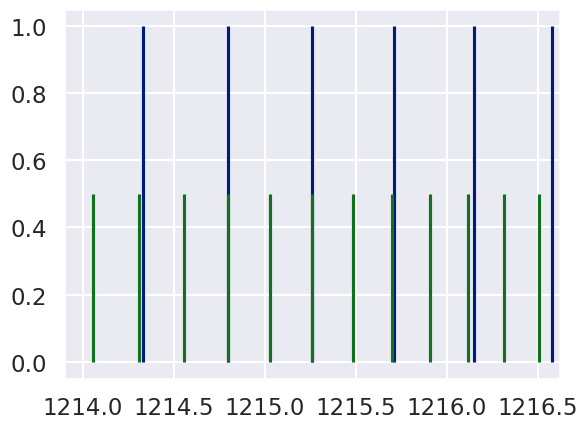

In [18]:
ω_vec = (ω0 + d1*μ_vec + d2/2*(μ_vec**2))*1e-3
Ω_vec = (ω0 + D1*(M_vec) + D2/2*(M_vec)**2)*1e-3

f, ax = plt.subplots()

ax.vlines(ω_vec, 0, 1)
ax.vlines(Ω_vec, 0, .5, color="C2")

ax.set_xlim(1e-3*(ω0 - d1*3), 1e-3*(ω0 + d1*3))

In [20]:
%matplotlib qt 

fig, [ax, axL] = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

for ind_ω, ω in enumerate(ω_vec):

    x = np.linspace(ω - .2, ω + .2, 100)
    y = 1 - lorentzian(x, ω, .5, .01)

    ax.plot(x, y, color="C0")

    x = np.linspace(ω - .1, ω + .1, 1000)
    yS = 1 - lorentzian(x, ωS[ind_ω], .5, .001)
    yC = 1 - lorentzian(x, ωC[ind_ω], .5, .001)
    yAS = 1 - lorentzian(x, ωAS[ind_ω], .5, .001)

    axL.plot(x, yS, color="C0")
    axL.plot(x, yC, color="C1")
    axL.plot(x, yAS, color="C2")

for Ω in Ω_vec:
    x = np.linspace(Ω - .1, Ω + .1, 100)
    y = .4 - lorentzian(x, Ω, .5, .01)
    # y = y/np.max(y)

    ax.plot(x, y, color="C1", alpha=.7)


# for ind_ω, ω in enumerate(ωC):

#     x = np.linspace(ω - 2, ω + 2, 100000)
#     yS = 1 - lorentzian(x, ωS[ind_ω], .5, .001)
#     yC = 1 - lorentzian(x, ωC[ind_ω], .5, .001)
#     yAS = 1 - lorentzian(x, ωAS[ind_ω], .5, .001)

#     axL.plot(x, yS, color="C0")
#     axL.plot(x, yC, color="C1")
#     axL.plot(x, yAS, color="C2")




# # ax.set_ylim(0, None)
ax.set_xlim(1e-3*(ω0 - d1*3), 1e-3*(ω0 + d1*3))

(1213.897075683131, 1216.621075683131)

In [ ]:
ωS, ω_vec

In [ ]:
%matplotlib qt
fig, ax = plt.subplots(figsize=(14, 4))


for ind_f, freq in enumerate(ωC):

    x = np.linspace(freq - 2, freq + 2, 100000)
    yS = 1 - lorentzian(x, ωS[ind_f], .5, .001)
    yC = 1 - lorentzian(x, ωC[ind_f], .5, .001)
    yAS = 1 - lorentzian(x, ωAS[ind_f], .5, .001)

    ax.plot(1e-3*x/(2*np.pi), yS, color="C0")
    ax.plot(1e-3*x/(2*np.pi), yC, color="C1")
    ax.plot(1e-3*x/(2*np.pi), yAS, color="C2")

# ax.set_xlim(1e-3*(f0 - d1*.5), 1e-3*(f0 + d1*.5))